# **TCC - PERFIS DE DESEMPENHO NO ENEM(2018–2023) EM MUNICÍPIOS DA ÁREA DE ABRANGÊNCIA DO IFNMG**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [113]:
import os
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

### **Realizando a leitura da base de área de MG**

In [114]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Codificação das variáveis**
Nesse caso, será realizado a transformação da variável **TP_SEXO**, convertendo o valor 'M' para 0 e o valor 'F' para 1.

In [115]:
df_final["TP_SEXO"] = df_final["TP_SEXO"].map({"F": 1, "M": 0})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, a variável **TP_ESTADO_CIVIL** foi recodificada para valores numéricos, de forma que Solteiro(a) foi representado por 0, Casado(a)/Companheiro(a) por 1, e as demais categorias (Divorciado(a), Desquitado(a), Separado(a) e Viúvo(a)) foram agrupadas sob o valor 2, representando o grupo “Outros”

In [116]:
df_final["TP_ESTADO_CIVIL"] = df_final["TP_ESTADO_CIVIL"].replace({
    "Solteiro(a)": 0,
    "Casado(a)/Companheiro(a)": 1,
    "Divorciado(a)/Separado(a)": 2,
    "Desquitado(a)": 2,
    "Viúvo(a)": 2
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, aplicou-se o método one-hot encoding à variável **TP_COR_RACA**, criando colunas binárias (0 e 1) para cada categoria de cor/raça. Essa transformação permite representar variáveis categóricas de forma numérica, sem atribuir uma ordem entre as categorias.

In [117]:
df_final = pd.get_dummies(df_final, columns=["TP_COR_RACA"], prefix="COR_RACA")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,1,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,1,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,1,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,1,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,1,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,3,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,1,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,1,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,1,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_NACIONALIDADE**, transformando as categorias originais em valores numéricos binários:

0 → Brasileiro(a), Brasileiro(a) Naturalizado(a) ou Brasileiro(a) Nato(a), nascido(a) no exterior

1 → Estrangeiro(a)

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [118]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_NACIONALIDADE"] != 0].copy()

df_final.loc[:, "TP_NACIONALIDADE"] = df_final["TP_NACIONALIDADE"].replace({
    1: 0,  # Brasileiro(a)
    2: 0,  # Brasileiro(a) Naturalizado(a)
    4: 0,  # Brasileiro(a) Nato(a), nascido(a) no exterior
    3: 1   # Estrangeiro(a)
})

depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517827
Total de linhas após a exclusão: 517522
Foram removidas 305 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_NACIONALIDADE**, o conjunto de dados passou de 517827 para 517522 registros, resultando na exclusão de 305 observações com nacionalidade “Não informada”.

Nesta etapa, será realizada a recodificação da variável **TP_ENSINO**, transformando as categorias originais em valores numéricos binários:

0 → Educação Especial – Modalidade Substitutiva e Educação de Jovens e Adultos

1 → Ensino Regular

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [119]:
df_final.loc[:, "TP_ENSINO"] = df_final["TP_ENSINO"].replace({
    2: 0,  # Educação Especial – Modalidade Substitutiva
    3: 0  # Educação de Jovens e Adultos
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_ESCOLA**, transformando as categorias originais em valores numéricos binários:

0 → Pública

1 → Exterior e Privada

As observações com valor 1 (Não respondeu) serão removidas do conjunto de dados.

In [120]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_ESCOLA"] != 1].copy()

df_final.loc[:, "TP_ESCOLA"] = df_final["TP_ESCOLA"].replace({
    2: 0,  # Pública
    3: 1,  # Exterior
    4: 1   # Privada
})
depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517522
Total de linhas após a exclusão: 511774
Foram removidas 5748 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_ESCOLA**, o conjunto de dados passou de 517522 para 511774 registros, resultando na exclusão de 5748 observações com nacionalidade “Não respondeu”.

Nesta etapa, será realizada a recodificação da variável **ESQ_PAI, ESC_MAE, OCU_PAI, OCU_MAE, RENDA_MENSAL, EMP_DOMESTICO, BANHEIRO, QTD_QUARTOS, CARRO, MOTO, GELADEIRA, FREEZER, LAVA_ROUPA, SECA_ROUPA, MICROONDAS, LAVA_LOUCA, ASPIRADOR, TV, DVD, TV_ASSINATURA, CELULAR, TELEFONE_FIXO, COMPUTADOR, INTERNET**, transformando as categorias originais em valores numéricos binários

In [121]:
colunas_categoricas = [
    'ESQ_PAI', 'ESC_MAE', 'OCU_PAI', 'OCU_MAE', 'RENDA_MENSAL',
    'EMP_DOMESTICO', 'BANHEIRO', 'QTD_QUARTOS', 'CARRO', 'MOTO',
    'GELADEIRA', 'FREEZER', 'LAVA_ROUPA', 'SECA_ROUPA', 'MICROONDAS',
    'LAVA_LOUCA', 'ASPIRADOR', 'TV', 'DVD', 'TV_ASSINATURA',
    'CELULAR', 'TELEFONE_FIXO', 'COMPUTADOR', 'INTERNET'
]
mapa = {chr(i + 65): i for i in range(26)}  # 'A'->0, 'B'->1, ..., 'Z'->25

for col in colunas_categoricas:
    df_final[col] = df_final[col].map(mapa)

df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,1.0,1.0,1.0,1.0,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,1.0,0.0,0.0,0.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,2.0,0.0,0.0,1.0,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,4.0,0.0,3.0,1.0,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,3.0,0.0,1.0,1.0,False,False,False,True,False,False


### **Filtrando a área de abrangencia do IFNMG**

In [122]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
6,2018,2,0,0.0,0,2,0,1.0,Chapada do Norte,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
9,2018,3,1,0.0,0,2,0,1.0,Teófilo Otoni,MG,...,4.0,0.0,1.0,1.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,0.0,2.0,1.0,False,False,False,True,False,False
517781,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,1.0,0.0,0.0,1.0,False,False,False,True,False,False
517789,2023,4,0,1.0,0,2,0,NaN,Teófilo Otoni,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517799,2023,2,0,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,1.0,2.0,1.0,False,False,False,True,False,False


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [125]:
df_scaler = df_ifnmg
excluir = ["NO_MUNICIPIO_ESC", "SG_UF_ESC"]

colunas_para_escalar = [c for c in df_scaler.columns if c not in excluir]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])
df_scaler

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_11388\4233387697.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,-1.108611,0.060143,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Rio Pardo de Minas,MG,...,0.500841,-0.295584,-0.803232,-1.731054,8.143051,-0.543132,-0.40194,-1.196244,-0.15566,-0.077428
1,-1.108611,-0.584541,0.815464,-1.466988,-0.02419,0.0,-0.321396,0.161927,São Francisco,MG,...,0.500841,-0.295584,-0.803232,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
4,-1.108611,-0.584541,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Montalvânia,MG,...,-0.429485,-0.295584,0.572921,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
6,-1.108611,-0.584541,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Chapada do Norte,MG,...,-0.429485,-0.295584,0.572921,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
9,-1.108611,0.060143,0.815464,-1.466988,-0.02419,0.0,-0.321396,0.161927,Teófilo Otoni,MG,...,1.431168,-0.295584,0.572921,0.577683,-0.122804,1.841172,-0.40194,-1.196244,-0.15566,-0.077428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,1.768912,0.060143,0.815464,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,1.431168,-0.295584,1.949074,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
517781,1.768912,0.060143,0.815464,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,-1.359812,-0.295584,-0.803232,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
517789,1.768912,0.704826,-1.226295,0.549446,-0.02419,0.0,-0.321396,NaN,Teófilo Otoni,MG,...,0.500841,-0.295584,-0.803232,0.577683,-0.122804,1.841172,-0.40194,-1.196244,-0.15566,-0.077428
517799,1.768912,-0.584541,-1.226295,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,1.431168,3.383129,1.949074,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

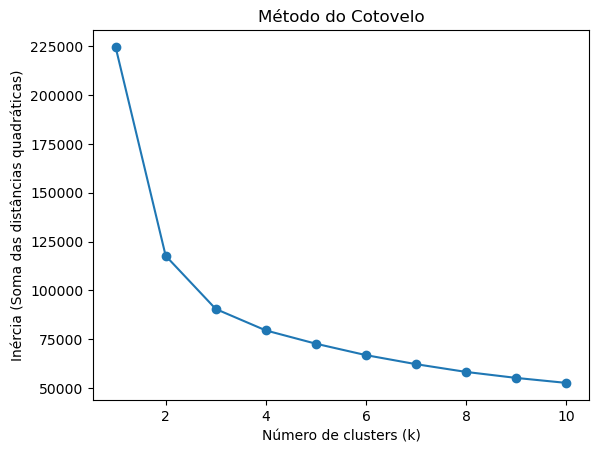

In [126]:
df_notas = df_ifnmg
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

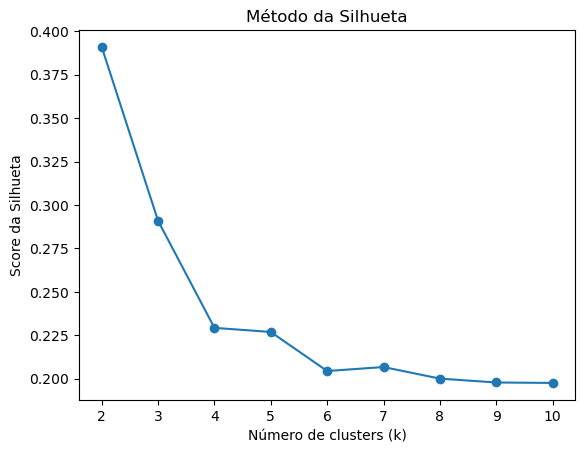

In [81]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Avaliação Interna do Agrupamento**

Para avaliar a qualidade dos agrupamentos obtidos, foram utilizadas duas métricas internas:
(a) a Soma das Distâncias Quadradas aos Centróides (SSQ), que mede a compacidade dos clusters, e
(b) a Razão entre Distância Intracluster e Intercluster (Intra/Inter), que avalia simultaneamente a coesão interna e a separação entre grupos.

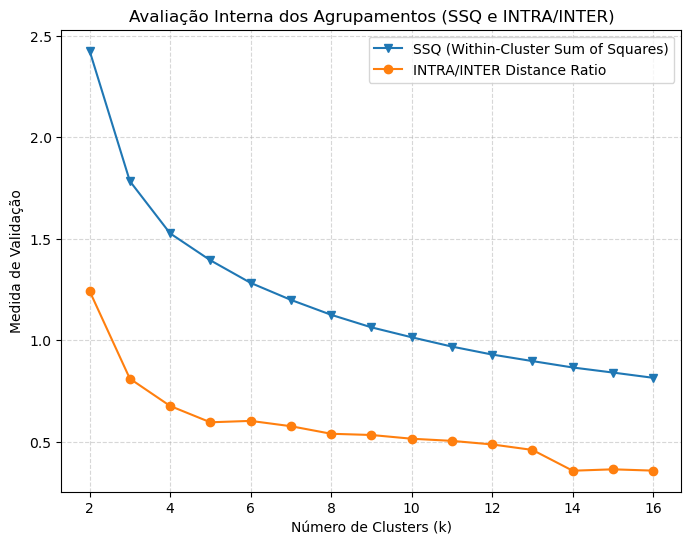

In [141]:
df_notas = df_ifnmg

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()  # Remove linhas com qualquer nota faltante

# Cria a média das notas
notas["MEDIA_GERAL"] = notas.mean(axis=1)

# Normaliza as colunas
scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

K = range(2, 17)
ssq_values = []
intra_inter_values = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_norm)
    
    ssq = kmeans.inertia_ / len(df_norm)
    ssq_values.append(ssq)
    
    intra_dists = []
    for label in np.unique(labels):
        cluster_points = df_norm[labels == label]
        if len(cluster_points) > 2:
            sample = cluster_points.sample(n=min(500, len(cluster_points)), random_state=42)
            intra = np.mean(pairwise_distances(sample))
        else:
            intra = 0
        intra_dists.append(intra)
    intra_mean = np.mean(intra_dists)
    
    centers = kmeans.cluster_centers_
    inter_mean = np.mean(pairwise_distances(centers))
    
    intra_inter_ratio = intra_mean / inter_mean
    intra_inter_values.append(intra_inter_ratio)

plt.figure(figsize=(8, 6))
plt.plot(K, ssq_values, 'v-', label='SSQ (Within-Cluster Sum of Squares)')
plt.plot(K, intra_inter_values, 'o-', label='INTRA/INTER Distance Ratio')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Medida de Validação")
plt.title("Avaliação Interna dos Agrupamentos (SSQ e INTRA/INTER)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## **Análise dos Clusters**

Médias e desvios por cluster:
        NU_NOTA_CN       NU_NOTA_CH       NU_NOTA_LC       NU_NOTA_MT        \
              mean   std       mean   std       mean   std       mean   std   
Cluster                                                                       
0            -0.37  0.60      -0.17  0.59      -0.12  0.53      -0.39  0.61   
1             0.45  0.61       0.58  0.52       0.58  0.51       0.41  0.65   
2            -0.88  0.63      -1.08  0.64      -1.12  0.69      -0.84  0.56   
3             1.53  0.61       1.34  0.50       1.31  0.52       1.58  0.62   

        MEDIA_GERAL        
               mean   std  
Cluster                    
0             -0.26  0.22  
1              0.51  0.24  
2             -0.98  0.30  
3              1.44  0.39  


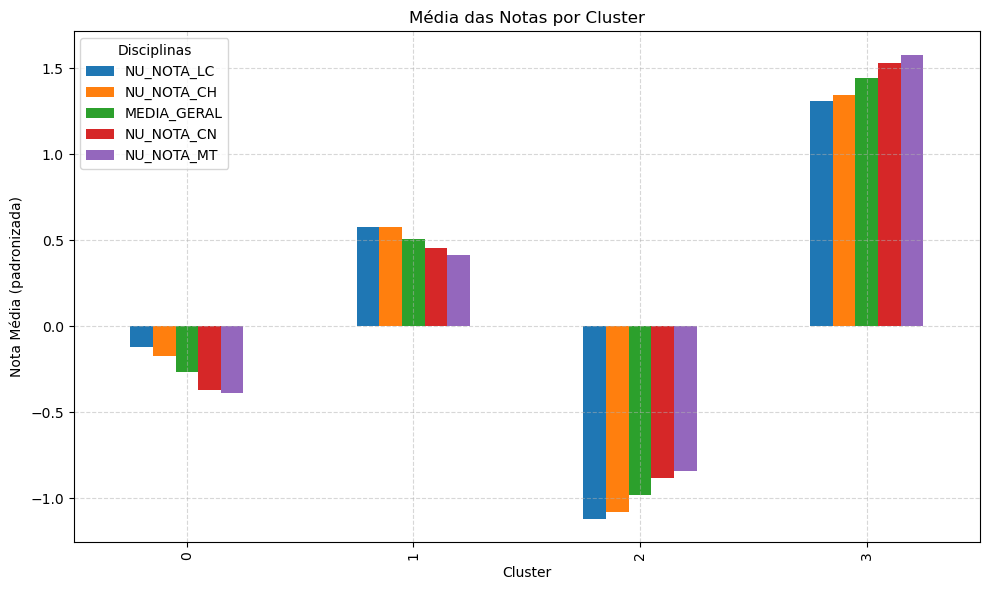

In [142]:
k = 4  # escolha com base no gráfico
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(df_norm)

notas["Cluster"] = labels_final

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

resumo_clusters = notas.groupby("Cluster")[colunas_notas + ["MEDIA_GERAL"]].agg(["mean", "std"]).round(2)
print("Médias e desvios por cluster:")
print(resumo_clusters)

resumo_mean = notas.groupby("Cluster")[colunas_notas + ["MEDIA_GERAL"]].mean()

ordem_cols = resumo_mean.mean(axis=0).sort_values(ascending=True).index
resumo_sorted = resumo_mean[ordem_cols]

ax = resumo_sorted.plot(kind="bar", figsize=(10, 6))
plt.title("Média das Notas por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Nota Média (padronizada)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Disciplinas")
plt.tight_layout()
plt.show()


## **Análise dos clusters com as notas sem normalizar**

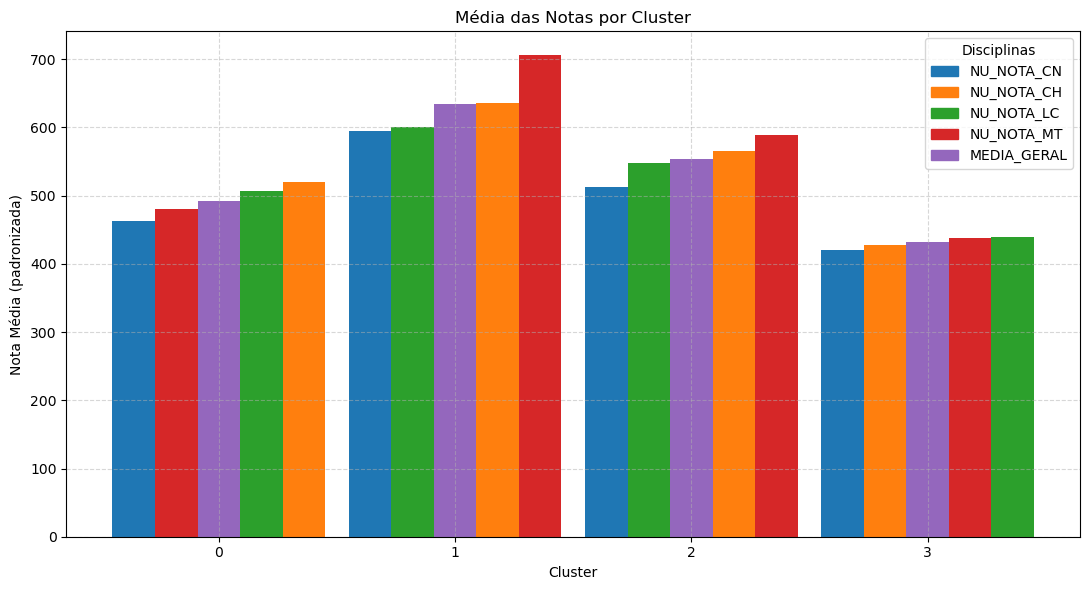

In [124]:
resumo_mean = notas.groupby("Cluster")[colunas_notas + ["MEDIA_GERAL"]].mean()

long = (
    resumo_mean.reset_index()
    .melt(id_vars="Cluster", var_name="Disciplina", value_name="Valor")
)

long["Rank"] = (
    long.groupby("Cluster")["Valor"]
        .rank(method="first", ascending=True)
        .astype(int)
)

palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
disciplinas = long["Disciplina"].unique().tolist()
cores = {d: palette[i % len(palette)] for i, d in enumerate(disciplinas)}

clusters = sorted(long["Cluster"].unique().tolist())
n_vars = long["Disciplina"].nunique()
width = 0.18

centros = {c: i for i, c in enumerate(clusters)}

offsets = {r: (r - (n_vars + 1) / 2) * width for r in range(1, n_vars + 1)}
long["x"] = long.apply(lambda r: centros[r["Cluster"]] + offsets[r["Rank"]], axis=1)


fig, ax = plt.subplots(figsize=(11, 6))
for _, row in long.iterrows():
    ax.bar(row["x"], row["Valor"], width=width, color=cores[row["Disciplina"]])

ax.set_xticks(list(centros.values()))
ax.set_xticklabels([str(c) for c in clusters])

from matplotlib.patches import Patch
handles = [Patch(color=cores[d], label=d) for d in disciplinas]
ax.legend(handles=handles, title="Disciplinas")

ax.set_title("Média das Notas por Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Nota Média (padronizada)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**

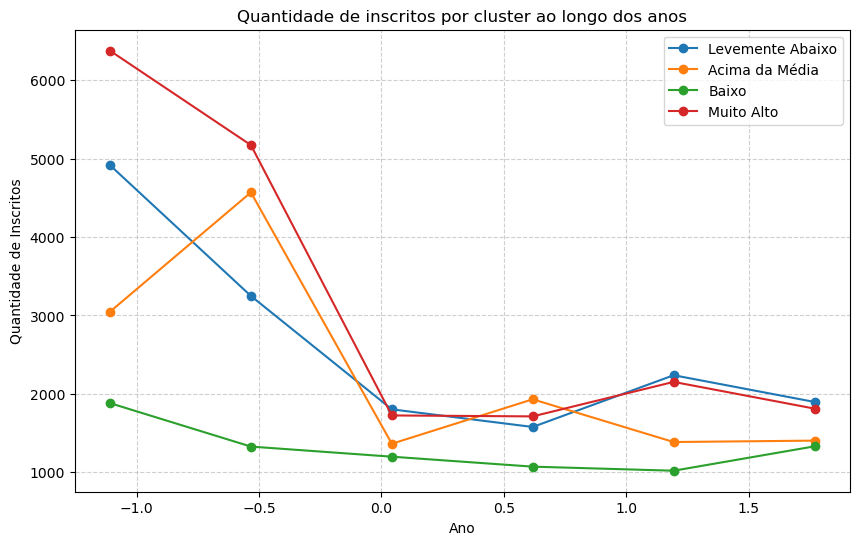

In [143]:
colunas_notas = ["NU_ANO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna()

notas["MEDIA_GERAL"] = notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].mean(axis=1)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
notas["Cluster"] = kmeans_final.fit_predict(
    notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]]
)

contagem = notas.groupby(["NU_ANO", "Cluster"]).size().reset_index(name="Quantidade")

# Mapeia os nomes dos clusters
cluster_nomes = {
    0: "Levemente Abaixo",
    1: "Acima da Média",
    2: "Baixo",
    3: "Muito Alto"
}
contagem["Cluster"] = contagem["Cluster"].map(cluster_nomes)

plt.figure(figsize=(10,6))
for nome in contagem["Cluster"].unique():
    df_plot = contagem[contagem["Cluster"] == nome]
    plt.plot(df_plot["NU_ANO"], df_plot["Quantidade"], marker="o", label=nome)

plt.title("Quantidade de inscritos por cluster ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Inscritos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## **Quantidade de inscritos por grupo**

In [134]:
tabela_clusters = notas["Cluster"].value_counts().sort_index().reset_index()
tabela_clusters.columns = ["Cluster", "Quantidade"]

cluster_nomes = {
    0: "Levemente Abaixo",
    1: "Acima da Média",
    2: "Baixo",
    3: "Muito Alto"
}
tabela_clusters["Grupo"] = tabela_clusters["Cluster"].map(cluster_nomes)

total = tabela_clusters["Quantidade"].sum()
tabela_clusters["Porcentagem"] = (tabela_clusters["Quantidade"] / total * 100).round(1)

linha_total = pd.DataFrame({
    "Cluster": ["-"],
    "Grupo": ["Total"],
    "Quantidade": [total],
    "Porcentagem": [100.0]
})
tabela_final = pd.concat([tabela_clusters, linha_total], ignore_index=True)

tabela_final["Quantidade"] = tabela_final["Quantidade"].apply(lambda x: f"{int(x):,}".replace(",", "."))

tabela_final["Porcentagem"] = tabela_final["Porcentagem"].apply(lambda x: f"{x:.0f}%")

tabela_final = tabela_final[["Grupo", "Quantidade", "Porcentagem"]]

print(tabela_final)

              Grupo Quantidade Porcentagem
0  Levemente Abaixo     15.682         28%
1    Acima da Média     13.703         24%
2             Baixo      7.832         14%
3        Muito Alto     18.953         34%
4             Total     56.170        100%


In [139]:
colunas_notas = ["NU_ANO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()

notas["MEDIA_GERAL"] = notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].mean(axis=1)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
notas["Cluster"] = kmeans_final.fit_predict(
    notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]]
)

contagem = notas.groupby(["NU_ANO", "Cluster"]).size().reset_index(name="Quantidade")

# Mapeia os nomes dos clusters
cluster_nomes = {
    0: "Levemente Abaixo",
    1: "Acima da Média",
    2: "Baixo",
    3: "Muito Alto"
}
contagem["Cluster"] = contagem["Cluster"].map(cluster_nomes)
# --- Formata números com ponto como separador de milhar ---

# --- Exibe ---
print("Tabela 5.2 — Quantidade de inscritos por grupo entre 2017 e 2022:\n")
print(contagem)


Tabela 5.2 — Quantidade de inscritos por grupo entre 2017 e 2022:

      NU_ANO           Cluster  Quantidade
0  -1.108611  Levemente Abaixo        4917
1  -1.108611    Acima da Média        3048
2  -1.108611             Baixo        1882
3  -1.108611        Muito Alto        6377
4  -0.533106  Levemente Abaixo        3249
5  -0.533106    Acima da Média        4570
6  -0.533106             Baixo        1328
7  -0.533106        Muito Alto        5173
8   0.042398  Levemente Abaixo        1803
9   0.042398    Acima da Média        1364
10  0.042398             Baixo        1199
11  0.042398        Muito Alto        1725
12  0.617903  Levemente Abaixo        1578
13  0.617903    Acima da Média        1931
14  0.617903             Baixo        1072
15  0.617903        Muito Alto        1713
16  1.193407  Levemente Abaixo        2238
17  1.193407    Acima da Média        1386
18  1.193407             Baixo        1020
19  1.193407        Muito Alto        2153
20  1.768912  Levemente Abaixo

## **TESTE**

Índice Rand Ajustado (ARI) entre K-Means e Birch: 0.366


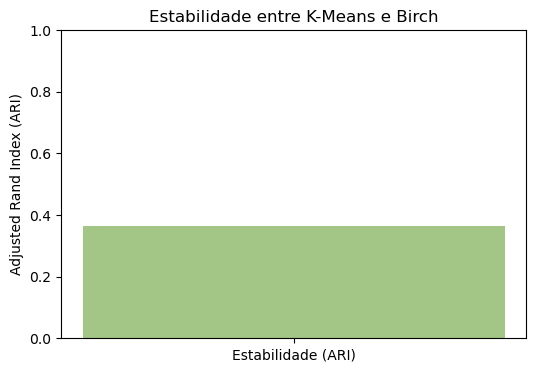

In [19]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, Birch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# ====== Pré-processamento ======
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()
notas["MEDIA_GERAL"] = notas.mean(axis=1)

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

# ====== Número de clusters ======
k = 4

# ====== Modelo 1: K-Means ======
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_norm)

# ====== Modelo 2: Birch ======
birch = Birch(n_clusters=k)
labels_birch = birch.fit_predict(df_norm)

# ====== Métrica de estabilidade ======
ari = adjusted_rand_score(labels_kmeans, labels_birch)
print(f"Índice Rand Ajustado (ARI) entre K-Means e Birch: {ari:.3f}")

# ====== Visualização ======
plt.figure(figsize=(6, 4))
plt.bar(["Estabilidade (ARI)"], [ari], color="#a3c585")
plt.ylim(0, 1)
plt.title("Estabilidade entre K-Means e Birch")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.show()


Índice Rand Ajustado (ARI) entre K-Means e MiniBatch K-Means: 0.639


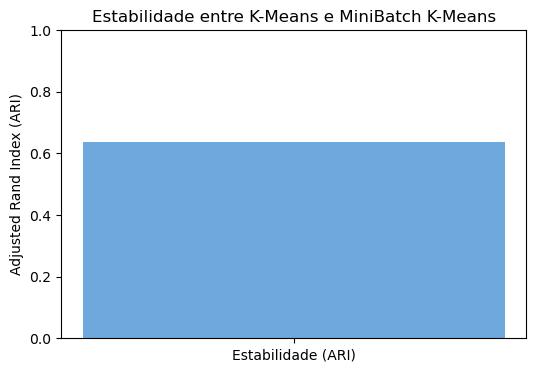

In [18]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# ====== Pré-processamento ======
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()
notas["MEDIA_GERAL"] = notas.mean(axis=1)

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

# ====== Número de clusters ======
k = 4

# ====== Modelo 1: K-Means tradicional ======
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_norm)

# ====== Modelo 2: MiniBatch K-Means ======
mini_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
labels_mini = mini_kmeans.fit_predict(df_norm)

# ====== Métrica de estabilidade ======
ari = adjusted_rand_score(labels_kmeans, labels_mini)
print(f"Índice Rand Ajustado (ARI) entre K-Means e MiniBatch K-Means: {ari:.3f}")

# ====== Visualização ======
plt.figure(figsize=(6, 4))
plt.bar(["Estabilidade (ARI)"], [ari], color="#6fa8dc")
plt.ylim(0, 1)
plt.title("Estabilidade entre K-Means e MiniBatch K-Means")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.show()
